# 03 — Feature Engineering
**Aviation Safety Risk Prediction — NTSB + NOAA Dataset**

### Changes vs v1
- **`crew_age` anomaly clamp removed** — it is now handled in NB01 (Section 11)
- `oper_individual_name` removed from `BINARY_YN_COLS` (was duplicated with `DROP_COLS`)
- All other logic identical to v1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

SEED = 42
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Load & Quick Inspect

In [2]:
df = pd.read_csv('../data/processed/ntsb_clean_final.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['ev_highest_injury'].value_counts())
print(f'\nClass imbalance NONE/FATL: {df["ev_highest_injury"].value_counts()["NONE"] / df["ev_highest_injury"].value_counts()["FATL"]:.2f}x')


Shape: (28810, 109)

Target distribution:
ev_highest_injury
NONE    16075
FATL     4810
MINR     4206
SERS     3719
Name: count, dtype: int64

Class imbalance NONE/FATL: 3.34x


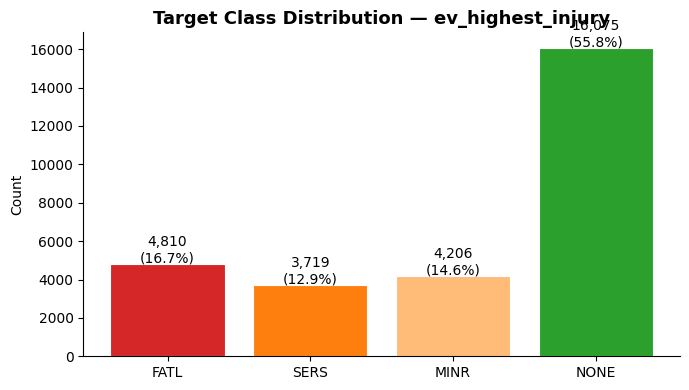

In [3]:
# Visual: target distribution
fig, ax = plt.subplots(figsize=(7, 4))
order  = ['FATL', 'SERS', 'MINR', 'NONE']
colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c']
vc = df['ev_highest_injury'].value_counts()[order]
ax.bar(order, vc.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(vc.values):
    ax.text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution — ev_highest_injury', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/target_distribution.png', dpi=150)
plt.show()


## 2. Anomaly Detection & Fixes
**crew_age clamp removed from this notebook** — it was moved to NB01 Section 11.  
We retain the other two anomaly fixes from v1.


In [4]:
# ── 2.1 Verify crew_age is already clean (from NB01) ─────────────────────
print('=== crew_age verification (should be clean from NB01) ===')
print(f'  crew_age < 16 : {(df["crew_age"] < 16).sum()} rows  (expected 0)')
print(f'  crew_age > 100: {(df["crew_age"] > 100).sum()} rows  (expected 0)')
print(f'  Range         : [{df["crew_age"].min():.0f}, {df["crew_age"].max():.0f}]')


=== crew_age verification (should be clean from NB01) ===
  crew_age < 16 : 0 rows  (expected 0)
  crew_age > 100: 0 rows  (expected 0)
  Range         : [16, 98]


In [5]:
# ── 2.2 afm_hrs == 0 ─────────────────────────────────────────────────────
print('=== afm_hrs == 0 ===')
print(f'  Count: {(df["afm_hrs"] == 0).sum()} rows')
mask_zero_hrs = (df['afm_hrs'] == 0) & (~df['is_missing_afm_hrs'].astype(bool))
print(f'  Replacing {mask_zero_hrs.sum()} non-flagged afm_hrs==0 with NaN')
df.loc[mask_zero_hrs, 'afm_hrs'] = np.nan


=== afm_hrs == 0 ===
  Count: 43 rows
  Replacing 43 non-flagged afm_hrs==0 with NaN


In [6]:
# ── 2.3 Gust with zero wind ───────────────────────────────────────────────
n_inconsistent = ((df['noaa_gust_knots'].notna()) & (df['noaa_wind_knots'] == 0)).sum()
print(f'=== noaa_gust present but noaa_wind_knots == 0 ===')
print(f'  Count: {n_inconsistent} rows')
mask_gust_no_wind = (df['noaa_gust_knots'].notna()) & (df['noaa_wind_knots'] == 0)
df.loc[mask_gust_no_wind, 'noaa_wind_knots'] = df.loc[mask_gust_no_wind, 'noaa_gust_knots']
print(f'  Fixed: set noaa_wind_knots = noaa_gust_knots for those rows')


=== noaa_gust present but noaa_wind_knots == 0 ===
  Count: 107 rows
  Fixed: set noaa_wind_knots = noaa_gust_knots for those rows


## 3. `acft_make` Consolidation

In [7]:
df['acft_make'] = df['acft_make'].str.upper().str.strip()

make_aliases = {
    'ROBINSON HELICOPTER COMPANY': 'ROBINSON', 'ROBINSON HELICOPTER': 'ROBINSON',
    'CIRRUS DESIGN CORP': 'CIRRUS',            'CIRRUS DESIGN': 'CIRRUS',
    'DIAMOND AIRCRAFT IND INC': 'DIAMOND',     'DIAMOND AIRCRAFT': 'DIAMOND',
    'AIR TRACTOR INC': 'AIR TRACTOR',          'BOMBARDIER INC': 'BOMBARDIER',
    'DEHAVILLAND': 'DE HAVILLAND',             'DE HAVILLAND CANADA': 'DE HAVILLAND',
}
df['acft_make'] = df['acft_make'].replace(make_aliases)

TOP_N_MAKES = 25
top_makes = df['acft_make'].value_counts().head(TOP_N_MAKES).index.tolist()
df['acft_make_grouped'] = df['acft_make'].apply(lambda x: x if x in top_makes else 'OTHER')
print(f'Unique acft_make_grouped: {df["acft_make_grouped"].nunique()}')
print(df['acft_make_grouped'].value_counts())


Unique acft_make_grouped: 26
acft_make_grouped
OTHER             9608
CESSNA            7038
PIPER             4198
BEECH             1623
ROBINSON           847
BOEING             831
BELL               593
CIRRUS             469
AIR TRACTOR        376
MOONEY             358
AIRBUS             239
SCHWEIZER          226
BELLANCA           214
DE HAVILLAND       213
AERONCA            211
MAULE              192
DIAMOND            184
HUGHES             180
BOMBARDIER         170
VANS               169
CHAMPION           158
LUSCOMBE           147
EMBRAER            146
STINSON            144
EUROCOPTER         143
NORTH AMERICAN     133
Name: count, dtype: int64


## 4. Derived Features

In [8]:
# ── 4.1 Weather flags ─────────────────────────────────────────────────────
df['adverse_weather'] = (
    df['noaa_fog'].astype(bool) | df['noaa_rain'].astype(bool) |
    df['noaa_snow'].astype(bool) | df['noaa_thunder'].astype(bool)
).astype(int)

df['poor_visibility'] = (df['vis_km'] < 5).astype(int)      # ICAO VMC minima
df['high_wind']       = (df['noaa_wind_knots'] > 25).astype(int)
df['extreme_temp']    = ((df['noaa_temp_c'] < -20) | (df['noaa_temp_c'] > 35)).astype(int)
df['td_spread']       = df['wx_temp_c'] - df['wx_dew_pt_c']
df['fog_risk']        = (df['td_spread'] < 3).astype(int)   # T-D spread < 3°C
df['is_imc']          = (df['wx_cond_basic'] == 'IMC').astype(int)

print('Weather flags:')
for col in ['adverse_weather','poor_visibility','high_wind','extreme_temp','fog_risk','is_imc']:
    print(f'  {col}: {df[col].sum():,} positive ({df[col].mean()*100:.1f}%)')


Weather flags:
  adverse_weather: 8,337 positive (28.9%)
  poor_visibility: 742 positive (2.6%)
  high_wind: 16 positive (0.1%)
  extreme_temp: 159 positive (0.6%)
  fog_risk: 4,991 positive (17.3%)
  is_imc: 1,375 positive (4.8%)


In [9]:
# ── 4.2 Maintenance ratio ─────────────────────────────────────────────────
eps = 1e-3
df['maintenance_ratio'] = (
    (df['afm_hrs'] - df['afm_hrs_last_insp']).clip(lower=0) / (df['afm_hrs'] + eps)
).clip(0, 1)
print('maintenance_ratio stats:')
print(df['maintenance_ratio'].describe())


maintenance_ratio stats:
count    28767.000000
mean         0.944548
std          0.169827
min          0.000000
25%          0.981875
50%          0.992368
75%          0.995151
max          1.000000
Name: maintenance_ratio, dtype: float64


In [10]:
# ── 4.3 Cyclical time features ────────────────────────────────────────────
df['ev_hour'] = (df['ev_time'] // 100).clip(0, 23)
df['hour_sin'] = np.sin(2 * np.pi * df['ev_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['ev_hour'] / 24)

dow_map = {'Mo':0,'Tu':1,'We':2,'Th':3,'Fr':4,'Sa':5,'Su':6}
df['ev_dow_num'] = df['ev_dow'].map(dow_map)
df['dow_sin'] = np.sin(2 * np.pi * df['ev_dow_num'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['ev_dow_num'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['ev_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['ev_month'] / 12)
print('Cyclical time features: ev_hour, hour_sin/cos, dow_sin/cos, month_sin/cos')


Cyclical time features: ev_hour, hour_sin/cos, dow_sin/cos, month_sin/cos


In [11]:
# ── 4.4 Aircraft age ─────────────────────────────────────────────────────
df['acft_age'] = (df['ev_year'] - df['acft_year']).clip(lower=0, upper=80)
print('acft_age stats:'); print(df['acft_age'].describe())

# ── 4.5 Gust excess ───────────────────────────────────────────────────────
df['gust_excess'] = (df['noaa_gust_knots'] - df['noaa_wind_knots']).clip(lower=0).fillna(0)
print('gust_excess stats:'); print(df['gust_excess'].describe())


acft_age stats:
count    28810.000000
mean        31.907324
std         18.081239
min          0.000000
25%         22.000000
50%         28.000000
75%         43.000000
max         80.000000
Name: acft_age, dtype: float64
gust_excess stats:
count    28810.000000
mean        15.877397
std          4.535826
min          0.000000
25%         13.000000
50%         16.000000
75%         18.300000
max         74.200000
Name: gust_excess, dtype: float64


weather_risk_score distribution:
weather_risk_score
0    17813
1     7890
2     2016
3      666
4      425
Name: count, dtype: int64


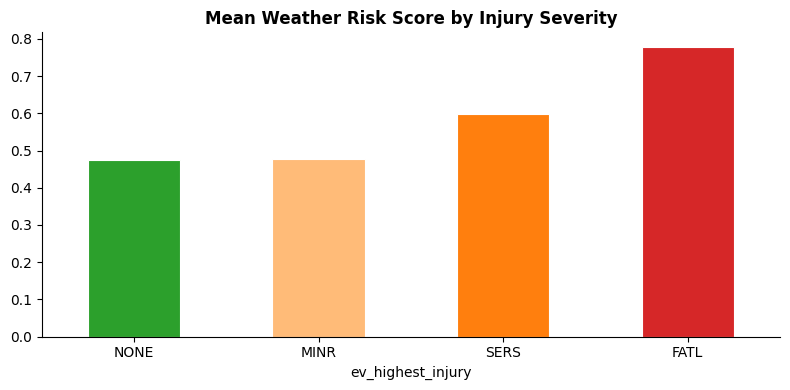

In [12]:
# ── 4.6 Weather severity score (for EDA/dashboard only) ──────────────────
df['weather_risk_score'] = (
    df['adverse_weather'] + df['poor_visibility'] + df['high_wind'] +
    df['extreme_temp'] + df['fog_risk'] + df['is_imc']
)
print('weather_risk_score distribution:')
print(df['weather_risk_score'].value_counts().sort_index())

# Quick EDA plot
fig, ax = plt.subplots(figsize=(8, 4))
order = ['NONE','MINR','SERS','FATL']
df.groupby('ev_highest_injury')['weather_risk_score'].mean()[order].plot(
    kind='bar', ax=ax, color=['#2ca02c','#ffbb78','#ff7f0e','#d62728'],
    edgecolor='white', linewidth=0.8)
ax.set_title('Mean Weather Risk Score by Injury Severity', fontsize=12, fontweight='bold')
ax.set_xticklabels(order, rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/weather_risk_by_severity.png', dpi=150)
plt.show()


## 5. Log Transforms

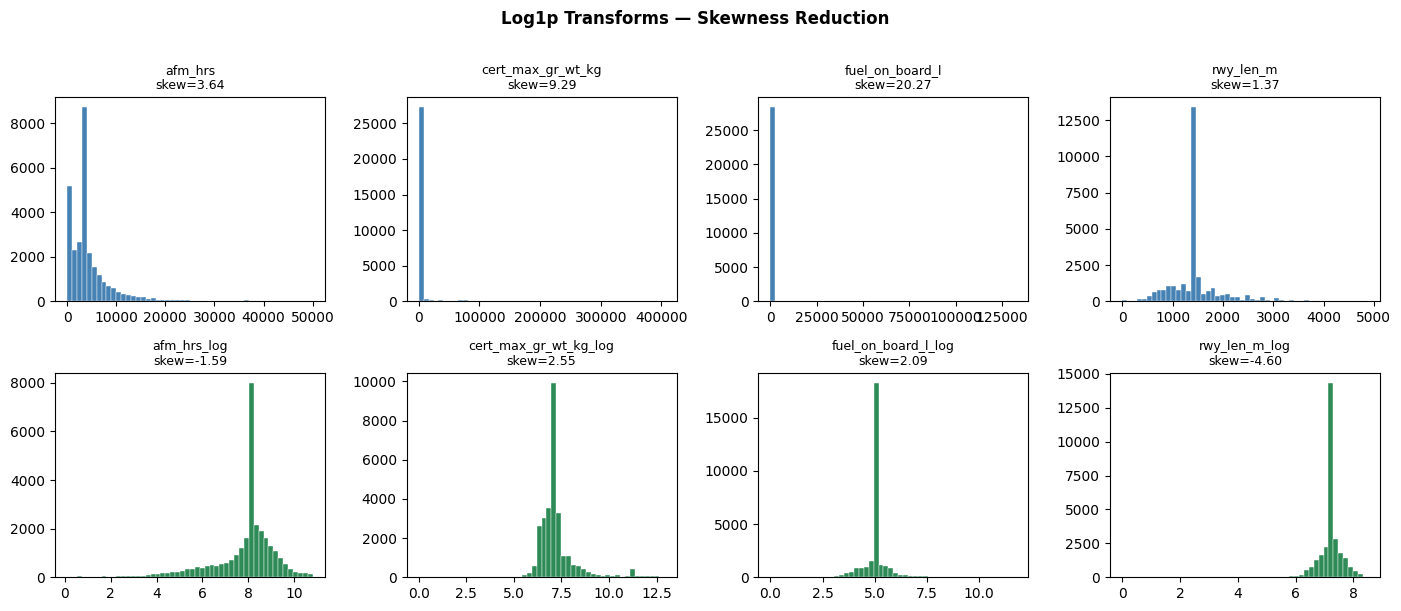

Log columns: ['afm_hrs_log', 'cert_max_gr_wt_kg_log', 'fuel_on_board_l_log', 'rwy_len_m_log']


In [13]:
LOG_COLS = ['afm_hrs','cert_max_gr_wt_kg','fuel_on_board_l','rwy_len_m']
LOG_COLS = [c for c in LOG_COLS if c in df.columns]

fig, axes = plt.subplots(2, len(LOG_COLS), figsize=(14, 6))
for i, col in enumerate(LOG_COLS):
    axes[0, i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=9)
    df[f'{col}_log'] = np.log1p(df[col])
    axes[1, i].hist(df[f'{col}_log'].dropna(), bins=50, color='seagreen', edgecolor='white', linewidth=0.3)
    axes[1, i].set_title(f'{col}_log\nskew={df[col+"_log"].skew():.2f}', fontsize=9)

plt.suptitle('Log1p Transforms — Skewness Reduction', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Log columns:', [f'{c}_log' for c in LOG_COLS])


## 6. Feature Column Groups

In [14]:
DROP_COLS = [
    'Aircraft_Key', 'oper_individual_name',   # ← removed from BINARY_YN (was a duplicate)
    'acft_make', 'acft_model', 'acft_series', 'rwy_num',
    'elt_manufacturer', 'elt_model',
    'ev_time', 'ev_dow', 'ev_month', 'ev_dow_num', 'wx_cond_basic',
    'afm_hrs', 'cert_max_gr_wt_kg', 'fuel_on_board_l', 'rwy_len_m',
    'ev_highest_injury', 'weather_risk_score',
]

BINARY_YN_COLS = [         # oper_individual_name REMOVED from here
    'homebuilt', 'second_pilot', 'afm_hrs_since',
    'elt_install', 'elt_oper',
    'crew_tox_perf', 'latlong_acq', 'ev_nr_apt_loc',
    'wind_dir_ind', 'wind_vel_ind', 'gust_ind', 'pilot_flying',
]

NUMERIC_BINARY_COLS = [
    'noaa_fog', 'noaa_rain', 'noaa_snow', 'noaa_thunder',
    'adverse_weather', 'poor_visibility', 'high_wind',
    'extreme_temp', 'fog_risk', 'is_imc',
    'is_missing_rwy_len', 'is_missing_rwy_width', 'is_missing_pax_seats',
    'is_missing_crew_age', 'is_missing_fuel_on_board', 'is_missing_afm_hrs',
    'is_missing_afm_hrs_last_insp', 'is_missing_acft_year', 'is_missing_wind_vel_kts',
]

OHE_COLS = [
    'acft_category', 'ev_season', 'light_cond',
    'sky_cond_nonceil', 'sky_cond_ceil', 'wx_src_iic',
    'type_last_insp', 'crew_category', 'med_certf',
    'med_crtf_vldty', 'fixed_retractable', 'acft_make_grouped', 'seat_occ_pic',
]

OHE_HIGH_COLS = [
    'ev_state', 'far_part', 'type_fly', 'flt_plan_filed',
    'flight_plan_activated', 'pc_profession', 'infl_rest_inst',
    'dprt_pt_same_ev', 'elt_type', 'available_restraint',
    'restraint_used', 'med_crtf_limit',
]

ORDINAL_COLS = ['crew_sex']

NUMERIC_COLS = [
    'noaa_temp_c', 'noaa_temp_max_c', 'noaa_temp_min_c',
    'noaa_wind_knots', 'noaa_maxwind_knots', 'noaa_gust_knots',
    'noaa_slp_hpa', 'noaa_visib_km', 'noaa_prcp_mm', 'noaa_dist_km',
    'gust_excess', 'wx_temp_c', 'wx_dew_pt_c',
    'wind_dir_deg', 'wind_vel_kts', 'gust_kts', 'vis_km',
    'sky_ceil_ht_m', 'sky_nonceil_ht_m', 'altimeter_hpa', 'td_spread',
    'apt_elev_m', 'apt_dist_km', 'wx_obs_elev_m', 'wx_obs_dist_km',
    'rwy_width_m', 'rwy_len_m_log', 'num_eng', 'fc_seats', 'pax_seats',
    'total_seats', 'afm_hrs_log', 'afm_hrs_last_insp',
    'cert_max_gr_wt_kg_log', 'fuel_on_board_l_log',
    'acft_age', 'maintenance_ratio', 'crew_age',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'ev_year', 'wx_obs_time',
]


In [15]:
# Sanity check: no column assigned to multiple groups
all_assigned = set(BINARY_YN_COLS + NUMERIC_BINARY_COLS + OHE_COLS +
                   OHE_HIGH_COLS + ORDINAL_COLS + NUMERIC_COLS + DROP_COLS)
all_cols = set(df.columns)
unassigned = all_cols - all_assigned
print(f'Unassigned columns ({len(unassigned)}):', sorted(unassigned))

feature_groups = [BINARY_YN_COLS, NUMERIC_BINARY_COLS, OHE_COLS, OHE_HIGH_COLS, ORDINAL_COLS, NUMERIC_COLS]
names = ['BINARY_YN','NUMERIC_BINARY','OHE','OHE_HIGH','ORDINAL','NUMERIC']
for i in range(len(feature_groups)):
    for j in range(i+1, len(feature_groups)):
        overlap = set(feature_groups[i]) & set(feature_groups[j])
        if overlap:
            print(f'WARNING overlap {names[i]} ∩ {names[j]}: {overlap}')
print("Group checks done ✓")


Unassigned columns (11): ['acft_year', 'apt_dir', 'crew_no', 'dec_latitude', 'dec_longitude', 'dprt_time', 'elt_connected_antenna', 'elt_mounted_aircraft', 'ev_hour', 'ifr_equipped_cert', 'wx_obs_dir']
Group checks done ✓


## 7. Target Encoding & Stratified 60/20/20 Split

In [16]:
injury_order = {'NONE':0,'MINR':1,'SERS':2,'FATL':3}
y = df['ev_highest_injury'].map(injury_order)

FEATURE_COLS = (BINARY_YN_COLS + NUMERIC_BINARY_COLS +
                OHE_COLS + OHE_HIGH_COLS + ORDINAL_COLS + NUMERIC_COLS)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
for col in X.columns:
    if hasattr(X[col].dtype, 'name') and X[col].dtype.name == 'string':
        X[col] = X[col].astype(object)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y distribution: {dict(y.value_counts().sort_index())}')


X shape: (28810, 103)
y shape: (28810,)
y distribution: {0: np.int64(16075), 1: np.int64(4206), 2: np.int64(3719), 3: np.int64(4810)}


In [17]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

print(f'Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val  : {X_val.shape[0]:,}   rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test : {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.1f}%)')


Train: 17,286 rows (60.0%)
Val  : 5,762   rows (20.0%)
Test : 5,762  rows (20.0%)


## 8. sklearn Preprocessing Pipeline (ColumnTransformer)

In [18]:
binary_yn_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

binary_num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

ohe_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

ohe_high_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary_yn',  binary_yn_transformer,  [c for c in BINARY_YN_COLS     if c in X.columns]),
        ('binary_num', binary_num_transformer, [c for c in NUMERIC_BINARY_COLS if c in X.columns]),
        ('ohe',        ohe_transformer,        [c for c in OHE_COLS            if c in X.columns]),
        ('ohe_high',   ohe_high_transformer,   [c for c in OHE_HIGH_COLS       if c in X.columns]),
        ('ordinal',    ordinal_transformer,    [c for c in ORDINAL_COLS        if c in X.columns]),
        ('numeric',    numeric_transformer,    [c for c in NUMERIC_COLS        if c in X.columns]),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
print('ColumnTransformer assembled ✓')


ColumnTransformer assembled ✓


In [19]:
# Fit on TRAIN only
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f'X_train_processed: {X_train_processed.shape}')
print(f'X_val_processed  : {X_val_processed.shape}')
print(f'X_test_processed : {X_test_processed.shape}')


X_train_processed: (17286, 1518)
X_val_processed  : (5762, 1518)
X_test_processed : (5762, 1518)


In [20]:
try:
    feature_names = preprocessor.get_feature_names_out()
    print(f'Total features after encoding: {len(feature_names)}')
except Exception as e:
    print(f'Could not retrieve feature names: {e}')
    feature_names = None

if feature_names is not None:
    X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
    X_val_df   = pd.DataFrame(X_val_processed,   columns=feature_names)
    X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)
else:
    X_train_df = pd.DataFrame(X_train_processed)
    X_val_df   = pd.DataFrame(X_val_processed)
    X_test_df  = pd.DataFrame(X_test_processed)


Total features after encoding: 1518


## 9. VarianceThreshold — Remove Near-Zero Variance Features

In [21]:
vt = VarianceThreshold(threshold=1e-4)
X_train_vt = vt.fit_transform(X_train_processed)
X_val_vt   = vt.transform(X_val_processed)
X_test_vt  = vt.transform(X_test_processed)

if feature_names is not None:
    feature_names_vt = [feature_names[i] for i in range(len(feature_names)) if vt.get_support()[i]]
else:
    feature_names_vt = None

print(f"Before VarianceThreshold : {X_train_processed.shape[1]} features")
print(f"After  VarianceThreshold : {X_train_vt.shape[1]} features")
print(f"Removed                  : {X_train_processed.shape[1] - X_train_vt.shape[1]} features")


Before VarianceThreshold : 1518 features
After  VarianceThreshold : 515 features
Removed                  : 1003 features


## 10. Sanity Checks

In [22]:
label_map = {0:'NONE',1:'MINR',2:'SERS',3:'FATL'}

for name, arr in [('X_train',X_train_vt),('X_val',X_val_vt),('X_test',X_test_vt)]:
    nans = np.isnan(arr).sum()
    infs = np.isinf(arr).sum()
    print(f'{name}: NaNs={nans}  Infs={infs}  {"✓" if nans+infs==0 else "WARNING"}')

print('\nTarget distribution verification (%):')
for name, y_split in [('train',y_train),('val',y_val),('test',y_test)]:
    dist = (y_split.value_counts(normalize=True).sort_index() * 100).round(1)
    dist.index = [label_map[i] for i in dist.index]
    print(f'  {name}: {dict(dist)}')


X_train: NaNs=0  Infs=0  ✓
X_val: NaNs=0  Infs=0  ✓
X_test: NaNs=0  Infs=0  ✓

Target distribution verification (%):
  train: {'NONE': np.float64(55.8), 'MINR': np.float64(14.6), 'SERS': np.float64(12.9), 'FATL': np.float64(16.7)}
  val: {'NONE': np.float64(55.8), 'MINR': np.float64(14.6), 'SERS': np.float64(12.9), 'FATL': np.float64(16.7)}
  test: {'NONE': np.float64(55.8), 'MINR': np.float64(14.6), 'SERS': np.float64(12.9), 'FATL': np.float64(16.7)}


## 11. Class Weights

In [23]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print('Class weights (pass to model class_weight parameter):')
for k, v in class_weight_dict.items():
    print(f'  {label_map[k]}: {v:.4f}')


Class weights (pass to model class_weight parameter):
  NONE: 0.4481
  MINR: 1.7122
  SERS: 1.9370
  FATL: 1.4974


## 12. Save Artefacts

In [24]:
X_train_df_vt = pd.DataFrame(X_train_vt, columns=feature_names_vt)
X_val_df_vt   = pd.DataFrame(X_val_vt,   columns=feature_names_vt)
X_test_df_vt  = pd.DataFrame(X_test_vt,  columns=feature_names_vt)

X_train_df_vt.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_val_df_vt.to_csv(f'{OUTPUT_DIR}/X_val.csv',     index=False)
X_test_df_vt.to_csv(f'{OUTPUT_DIR}/X_test.csv',   index=False)

y_train.to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_val.to_csv(f'{OUTPUT_DIR}/y_val.csv',     index=False)
y_test.to_csv(f'{OUTPUT_DIR}/y_test.csv',   index=False)

joblib.dump(preprocessor,     f'{OUTPUT_DIR}/preprocessing_pipeline.pkl')
joblib.dump(vt,               f'{OUTPUT_DIR}/variance_threshold.pkl')
joblib.dump(class_weight_dict,f'{OUTPUT_DIR}/class_weights.pkl')

if feature_names_vt:
    pd.Series(feature_names_vt).to_csv(f'{OUTPUT_DIR}/feature_names.csv', index=False)

print("All artefacts saved to outputs/")


All artefacts saved to outputs/
